# Smoking &amp; Drinking Detection — **M3: Modeling, Baselines &amp; Tuning**
### YOLOv8n · YOLO11n · YOLOv8s

**Feature.** Smoking &amp; drinking detection · **Goal.** Detect unsafe driver behaviour.

**Input:** 640×640 RGB &nbsp;|&nbsp; **Output classes:** `smoking (0)`, `drinking (1)` &nbsp;|&nbsp; **Metrics:** mAP@50, mAP@50‑95, Precision, Recall

---

### What this notebook is (and is *not*)
This notebook **starts from the already‑prepared dataset** produced by the data‑prep notebook
(`smoking_drinking_yolo_dataprep_balanced_large`). That notebook already performed
downloading, integrity validation, class harmonisation, EDA, deduplication, **real‑image class
balancing**, the image‑grouped stratified split, and bbox‑aware augmentation, and exported a
ready‑to‑train YOLOv8 dataset.

> **This notebook does NOT repeat EDA or preprocessing.** It consumes the exported dataset and
> proceeds directly to **modeling**.

It delivers every M3 requirement in order:

| # | M3 requirement | Section |
|---|----------------|---------|
| 1 | Model architecture selection | §3 |
| 2 | Architecture justification | §4 |
| 3 | Baseline performance (default config / pretrained) on a **candidate subset** | §5–§6 |
| 4 | Hyperparameter tuning (strategy, rationale, impact, comparison plots) | §7 |
| 5 | End‑to‑end setup (data‑flow → outputs) | §8 |
| 6 | Architecture visualization (diagram / flowchart) | §9 |
| — | Written report section | §10 |


## 1 · Environment setup
Install Ultralytics (YOLOv8 **and** YOLO11 live in the same package) and confirm the GPU.
Safe to re‑run.

In [6]:
# Quiet installs — skip anything already present.
%pip -q install "ultralytics>=8.3.0" pandas matplotlib seaborn pyyaml >/dev/null 2>&1

import os, glob, random, shutil, yaml, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import torch
from ultralytics import YOLO
import ultralytics
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Ultralytics :", ultralytics.__version__)
print("Torch       :", torch.__version__)
print("CUDA avail. :", torch.cuda.is_available(),
      "|", (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"))
print("Using device:", DEVICE)

Ultralytics : 8.4.96
Torch       : 2.11.0+cu128
CUDA avail. : True | Tesla T4
Using device: 0


## 2 · Mount Google Drive &amp; load the **prepared** dataset
The dataset lives on **Google Drive** (uploaded from the data‑prep notebook). We mount Drive and
point directly at it — no cleaning, no re‑splitting, no EDA.

The data‑prep notebook exported this exact structure:

```
smoking_drinking_yolo_balanced/
├── data.yaml            # nc: 2, names: ['smoking','drinking']
├── images/{train,val,test}/
└── labels/{train,val,test}/
```

**Set `DRIVE_DATASET_PATH`** below to wherever you put it in Drive. It accepts either the
**unzipped folder** or the exported **`.zip`** (which is unzipped once to fast local disk for
speed — training off a zip‑on‑Drive is slow).

In [10]:
# ── Mount Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")   # follow the auth prompt

# ── EDIT THIS: path to your dataset in Drive (folder OR .zip) ────────────────
DATASET_NAME = "smoking_drinking_yolo_balanced (1).zip"          # matches OUTPUT_ROOT in the prep notebook
DRIVE_DATASET_PATH = f"/content/drive/MyDrive/{DATASET_NAME}"      # ← change if yours differs
# e.g. a zip:  f"/content/drive/MyDrive/{DATASET_NAME}.zip"
# e.g. subfolder:  "/content/drive/MyDrive/datasets/smoking_drinking_yolo_balanced"
# ────────────────────────────────────────────────────────────────────────────

def _looks_like_dataset(d: Path) -> bool:
    return (d / "data.yaml").exists() and (d / "images" / "train").exists()

src = Path(DRIVE_DATASET_PATH)
assert src.exists(), (
    f"'{DRIVE_DATASET_PATH}' not found in Drive. Open the Files panel (left) → "
    "drive/MyDrive, locate your dataset folder or .zip, and copy its path here.")

if src.is_dir() and _looks_like_dataset(src):
    # Train directly off the Drive folder (fine for smaller sets).
    DATASET_DIR = src.resolve()
    print("Using dataset folder directly from Drive.")
elif src.suffix.lower() == ".zip" or src.is_file():
    # Unzip once to local SSD (much faster I/O than reading many files off Drive).
    DATASET_DIR = (Path("/content") / Path(DATASET_NAME).stem).resolve() # Fixed: Use .stem to remove the .zip extension
    if not _looks_like_dataset(DATASET_DIR):
        print(f"Unzipping {src} → {DATASET_DIR} … (one-time, faster training)")
        shutil.unpack_archive(str(src), str(DATASET_DIR))
    # Some zips nest one level (…/DATASET_NAME/DATASET_NAME) — auto-descend if needed.
    if not _looks_like_dataset(DATASET_DIR):
        for sub in DATASET_DIR.iterdir():
            if sub.is_dir() and _looks_like_dataset(sub):
                DATASET_DIR = sub.resolve(); break
    print("Using dataset unzipped to local disk.")
else:
    raise AssertionError(f"'{DRIVE_DATASET_PATH}' is neither a valid dataset folder nor a .zip.")

assert _looks_like_dataset(DATASET_DIR), (
    f"data.yaml / images/train not found under {DATASET_DIR}. "
    "Point DRIVE_DATASET_PATH at the folder that directly contains data.yaml.")

DATA_YAML = DATASET_DIR / "data.yaml"
print("Dataset dir :", DATASET_DIR)
print("data.yaml   :", DATA_YAML.exists())
print(yaml.safe_load(DATA_YAML.read_text()))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping /content/drive/MyDrive/smoking_drinking_yolo_balanced (1).zip → /content/smoking_drinking_yolo_balanced (1) … (one-time, faster training)
Using dataset unzipped to local disk.
Dataset dir : /content/smoking_drinking_yolo_balanced (1)
data.yaml   : True
{'path': '.', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 2, 'names': ['smoking', 'drinking']}


In [13]:
# Quick integrity check of the hand-off (counts only — NOT EDA/preprocessing).
CLASS_NAMES = yaml.safe_load(DATA_YAML.read_text())["names"]
CLASS_NAMES = list(CLASS_NAMES.values()) if isinstance(CLASS_NAMES, dict) else list(CLASS_NAMES)
NC = len(CLASS_NAMES)

def split_counts(root: Path):
    rows = []
    for sp in ["train", "val", "test"]:
        imgs = list((root / "images" / sp).glob("*.*")) # Fixed: Added missing double quote
        lbls = list((root / "labels" / sp).glob("*.txt"))
        # instance counts per class from the label files
        inst = {c: 0 for c in range(NC)}
        for lb in lbls:
            for ln in lb.read_text().splitlines():
                if ln.strip():
                    # Fixed: Convert to float first, then to int, to handle '1.0'
                    inst[int(float(ln.split()[0]))] += 1
        rows.append({"split": sp, "images": len(imgs), "label_files": len(lbls),
                     **{CLASS_NAMES[c]: inst[c] for c in range(NC)}})
    return pd.DataFrame(rows)

df_counts = split_counts(DATASET_DIR)
print("Classes:", {i: n for i, n in enumerate(CLASS_NAMES)})
display(df_counts)
print("\nThis is the *prepared* dataset — we train on it as-is.")

Classes: {0: 'smoking', 1: 'drinking'}


,split,images,label_files,smoking,drinking
0,train,8884,8884,5050,5431
1,val,370,370,214,217
2,test,371,371,214,231



This is the *prepared* dataset — we train on it as-is.


## 3 · Model Architecture Selection

We evaluate **three single‑stage anchor‑free detectors** from the Ultralytics YOLO family, all
trained/evaluated at **640×640 RGB** for the two target classes:

| Model | Params (≈) | GFLOPs @640 (≈) | Role in our study |
|-------|-----------:|----------------:|-------------------|
| **YOLOv8n** | 3.2 M | 8.7 | Fastest baseline; edge/in‑cabin deployment target |
| **YOLO11n** | 2.6 M | 6.5 | Newer‑gen *nano*; more accuracy per FLOP (C3k2, C2PSA) |
| **YOLOv8s** | 11.2 M | 28.6 | Larger capacity; accuracy upper‑bound reference |

**Overall approach.** All three share the same detector paradigm — a **CSP‑style backbone**, a
**PAN‑FPN neck** for multi‑scale fusion, and a **decoupled, anchor‑free head** with
**distribution‑focal‑loss (DFL)** regression. This lets us hold the pipeline, data, and metrics
fixed and isolate the effect of **(a) architecture generation** (v8 → v11) and
**(b) model capacity** (n → s). We take **pretrained COCO weights** for each, adapt the head to
`nc = 2`, and fine‑tune. YOLO11n is the *architecture upgrade* axis; YOLOv8s is the *capacity*
axis; YOLOv8n is the common reference.

We deliberately **do not** design a custom backbone: the task is a well‑posed 2‑class detection
problem with a moderate‑sized, balanced dataset, where mature pretrained detectors transfer
strongly and are far more sample‑efficient than a from‑scratch custom net.

## 4 · Architecture Justification

**Suitability for our dataset &amp; problem.**
* **Real‑time, in‑cabin constraint.** Unsafe‑driver behaviour must be flagged live on limited
  hardware. YOLO single‑stage detectors run in one forward pass — the *nano* variants reach
  real‑time on a CPU/edge GPU, which two‑stage detectors (Faster R‑CNN) and transformer
  detectors (DETR) cannot match at the same cost.
* **Two well‑localised, medium‑sized objects** (a cigarette near the mouth, a bottle/cup at the
  hand/mouth). The dataset was **balanced with real images** (majority capped ≤1.25× minority)
  and split with **image‑grouped, class‑stratified** sampling, so a compact detector has enough
  signal without over‑augmenting. Nano models are a natural fit; the *s* variant probes whether
  extra capacity helps the harder, cluttered scenes seen in EDA (§7.2 of prep).
* **Anchor‑free + DFL head** removes anchor hyper‑parameters and handles the two different
  aspect ratios (thin cigarette vs. tall bottle) more gracefully than legacy anchor grids.

**Expected advantages over alternatives.**
* vs **Faster R‑CNN / two‑stage** — far lower latency &amp; memory; comparable AP at this scale.
* vs **DETR / RT‑DETR** — transformer detectors need much more data and longer schedules to
  converge; overkill for a 2‑class cabin task.
* vs **SSD / YOLOv5** — YOLOv8/11 give a stronger accuracy‑latency frontier and modern training
  tricks (mosaic, task‑aligned assigner, DFL) out of the box.
* **YOLO11n vs YOLOv8n** — YOLO11 replaces C2f with **C3k2** blocks and adds a **C2PSA**
  attention stage, giving more accuracy per FLOP with *fewer* parameters — attractive for edge
  deployment.

**Design decisions / modifications to the stock architecture.**
* Detection **head re‑initialised to `nc = 2`** (`smoking`, `drinking`); backbone/neck start from
  **COCO‑pretrained** weights (transfer learning).
* Fixed **`imgsz = 640`** per the spec (input contract).
* Heavy geometric/photometric augmentation was **already baked into the prepared train split**;
  we therefore start tuning from **lighter in‑training augmentation** to avoid double‑augmenting.

**Challenges / trade‑offs considered.**
* **Capacity vs latency** — YOLOv8s may win mAP but at ~3× params/FLOPs; we quantify the gap so
  the deployment choice is data‑driven, not assumed.
* **Small‑object recall** — cigarettes are small; §7.3 of prep flagged small‑object density, so
  we watch **Recall** and mAP@50‑95 closely, not just mAP@50.
* **Over‑augmentation risk** — the prep step already augments train images, so aggressive
  in‑loop mosaic can hurt; this becomes a tuning knob (§7).

**References.**
Redmon et al., *You Only Look Once*, CVPR 2016 · Jocher et al., *Ultralytics YOLOv8* (2023),
`github.com/ultralytics/ultralytics` · Ultralytics *YOLO11* (2024),
`docs.ultralytics.com/models/yolo11` · Lin et al., *Microsoft COCO*, ECCV 2014 (pretraining) ·
Li et al., *Generalized Focal Loss / DFL*, NeurIPS 2020.

## 5 · Candidate (representative) subset for rapid experimentation

Per the M3 note, we **do not** run every architecture/hyper‑parameter search on the full data.
We carve out a smaller **candidate subset** that is *statistically representative* of the full
prepared dataset, run all comparisons on it, then (M4) retrain the winner on the full set.

**How the subset is built (and why it is representative):**
1. **Stratified by dominant class.** For every image we read its label file and take its
   *dominant* class (`smoking`/`drinking`). We sample **within each class stratum** so the
   subset preserves the full set's class ratio — the same balancing the prep notebook worked to
   achieve is not undone.
2. **Split structure preserved.** We sample *inside* the existing `train/val/test` folders, so
   there is **no leakage** across splits (the prep split was image‑grouped &amp; stratified).
3. **Crowd distribution preserved.** Within a stratum images are drawn at random, so the
   boxes‑per‑image distribution (scene crowding) is retained in expectation.
4. **Fractions** are set so training is fast but the val/test folds stay large enough to give a
   stable metric read.

We then verify representativeness by comparing **class proportions** and **mean boxes/image**
between the full set and the subset.

In [15]:
# ── Subset configuration ────────────────────────────────────────────────────
SUBSET_FRACTIONS = {"train": 0.30, "val": 0.60, "test": 0.60}  # tune for your time budget
# Write the subset to LOCAL disk (not Drive): faster I/O + symlinks don't work on the Drive mount.
_local_root = Path("/content") if Path("/content").exists() else DATASET_DIR.parent
SUBSET_DIR = (_local_root / f"{DATASET_NAME}_candidate").resolve()
# ────────────────────────────────────────────────────────────────────────────

def dominant_class(label_path: Path):
    counts = {}
    for ln in label_path.read_text().splitlines():
        if ln.strip():
            # Fixed: Convert to float first, then to int, to handle '1.0'
            c = int(float(ln.split()[0])); counts[c] = counts.get(c, 0) + 1
    if not counts:
        return "background"
    return max(counts, key=counts.get)

def build_subset(src: Path, dst: Path, fracs: dict, seed=SEED):
    rng = random.Random(seed)
    if dst.exists():
        shutil.rmtree(dst)
    picked = {}
    for sp, frac in fracs.items():
        for sub in ["images", "labels"]:
            (dst / sub / sp).mkdir(parents=True, exist_ok=True)
        img_dir, lbl_dir = src / "images" / sp, src / "labels" / sp
        imgs = sorted(img_dir.glob("*.*"))
        # stratify by dominant class of the matching label
        strata = {}
        for im in imgs:
            lb = lbl_dir / (im.stem + ".txt")
            key = dominant_class(lb) if lb.exists() else "background"
            strata.setdefault(key, []).append(im)
        chosen = []
        for key, group in strata.items():
            rng.shuffle(group)
            k = max(1, int(round(len(group) * frac))) if group else 0
            chosen.extend(group[:k])
        # materialise as symlinks (fallback to copy) to avoid duplicating pixels
        for im in chosen:
            lb = lbl_dir / (im.stem + ".txt")
            for s, sub in [(im, "images"), (lb, "labels")]:
                if not s.exists():
                    continue
                d = dst / sub / sp / s.name
                try:
                    os.symlink(s.resolve(), d)
                except (OSError, NotImplementedError):
                    shutil.copy(s, d)
        picked[sp] = len(chosen)
    # write an absolute-path data.yaml for the subset
    (dst / "data.yaml").write_text(
        f"path: {dst}\ntrain: images/train\nval: images/val\ntest: images/test\n\n"
        f"nc: {NC}\nnames: {CLASS_NAMES}\n")
    return picked

picked = build_subset(DATASET_DIR, SUBSET_DIR, SUBSET_FRACTIONS)
SUBSET_YAML = SUBSET_DIR / "data.yaml"
print("Candidate subset:", SUBSET_DIR)
print("Images picked per split:", picked)


Candidate subset: /content/smoking_drinking_yolo_balanced (1).zip_candidate
Images picked per split: {'train': 2665, 'val': 222, 'test': 223}


,images,boxes/img,smoking,drinking
FULL,9625,1.180,0.482346,0.517654
CANDIDATE,3110,1.175,0.478785,0.521215


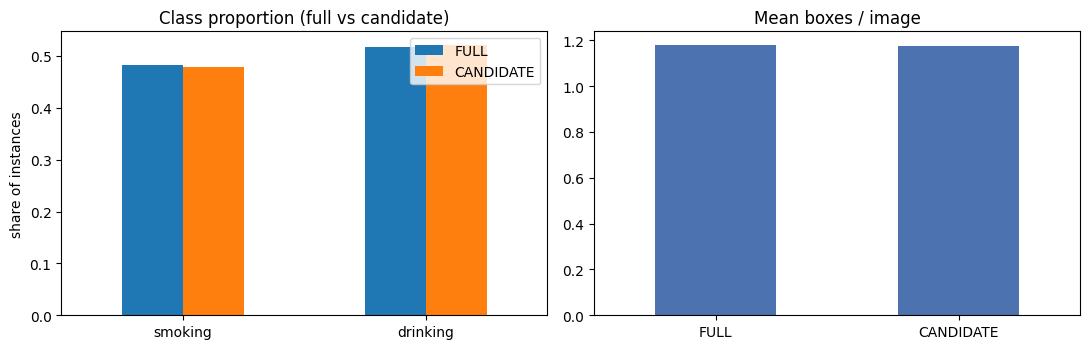

Close class proportions + similar boxes/image ⇒ the candidate subset is representative.


In [17]:
# ── Representativeness check: full vs candidate ─────────────────────────────
def profile(root: Path):
    inst = {c: 0 for c in range(NC)}
    n_imgs, n_boxes = 0, 0
    for sp in ["train", "val", "test"]:
        for lb in (root / "labels" / sp).glob("*.txt"):
            n_imgs += 1
            lines = [l for l in lb.read_text().splitlines() if l.strip()]
            n_boxes += len(lines)
            for ln in lines:
                # Fixed: Convert to float first, then to int, to handle '1.0'
                inst[int(float(ln.split()[0]))] += 1
    total = sum(inst.values()) or 1
    prop = {CLASS_NAMES[c]: inst[c] / total for c in range(NC)}
    return {"images": n_imgs, "boxes/img": round(n_boxes / max(n_imgs, 1), 3), **prop}

full_p  = profile(DATASET_DIR)
cand_p  = profile(SUBSET_DIR)
rep = pd.DataFrame([full_p, cand_p], index=["FULL", "CANDIDATE"])
display(rep)

# visual: class proportions side by side
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
rep[CLASS_NAMES].T.plot(kind="bar", ax=ax[0]); ax[0].set_title("Class proportion (full vs candidate)")
ax[0].set_ylabel("share of instances"); ax[0].tick_params(axis="x", rotation=0)
rep[["boxes/img"]].plot(kind="bar", ax=ax[1], legend=False, color=["#4C72B0", "#DD8452"])
ax[1].set_title("Mean boxes / image"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
print("Close class proportions + similar boxes/image ⇒ the candidate subset is representative.")


## 6 · Baseline model performance (default configuration)

We fine‑tune each architecture from its **COCO‑pretrained weights** using Ultralytics'
**default hyper‑parameters** (no tuning yet), on the **candidate subset**, for a short common
schedule. This is the reference every later improvement is measured against.

> Note on "pretrained‑only" evaluation: COCO has no `smoking`/`drinking` classes, so validating
> the raw pretrained model would score ~0 and be uninformative. The correct baseline for a
> custom‑class detector is **default‑config fine‑tuning** — that is what we report.

**Metrics reported:** Precision, Recall, mAP@50, mAP@50‑95 (on the subset's `val` fold).

In [18]:
# ── Baseline configuration ──────────────────────────────────────────────────
IMG_SIZE       = 640          # fixed by the input contract
EPOCHS_BASE    = 30           # short shared schedule for fair comparison (raise if time allows)
BATCH          = 16           # or -1 to auto-fit GPU memory
PROJECT_BASE   = "runs_m3/baseline"

BASELINE_MODELS = {
    "yolov8n": "yolov8n.pt",
    "yolo11n": "yolo11n.pt",
    "yolov8s": "yolov8s.pt",
}

def metrics_from_results(res):
    d = res.results_dict
    return {
        "precision":  d.get("metrics/precision(B)"),
        "recall":     d.get("metrics/recall(B)"),
        "mAP50":      d.get("metrics/mAP50(B)"),
        "mAP50-95":   d.get("metrics/mAP50-95(B)"),
    }

def train_eval(weights, name, data_yaml, epochs, project, **overrides):
    model = YOLO(weights)
    res = model.train(
        data=str(data_yaml), imgsz=IMG_SIZE, epochs=epochs, batch=BATCH,
        device=DEVICE, seed=SEED, project=project, name=name, exist_ok=True,
        verbose=False, plots=True, **overrides,
    )
    row = {"model": name, **metrics_from_results(res),
           "epochs": epochs, "run_dir": str(Path(res.save_dir))}
    return row, model

baseline_rows = []
for tag, w in BASELINE_MODELS.items():
    print(f"\n===== Baseline: {tag} =====")
    row, _ = train_eval(w, f"{tag}_base", SUBSET_YAML, EPOCHS_BASE, PROJECT_BASE)
    baseline_rows.append(row)

baseline_df = pd.DataFrame(baseline_rows).set_index("model")
print("\n================ BASELINE RESULTS (candidate subset / val) ================")
display(baseline_df[["precision", "recall", "mAP50", "mAP50-95"]].round(4))


===== Baseline: yolov8n =====
Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/smoking_drinking_yolo_balanced (1).zip_candidate/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_base, nb

,precision,recall,mAP50,mAP50-95
model,,,,
yolov8n_base,0.7678,0.7129,0.7476,0.3441
yolo11n_base,0.7208,0.7143,0.7606,0.3340
yolov8s_base,0.7393,0.7118,0.7403,0.3346


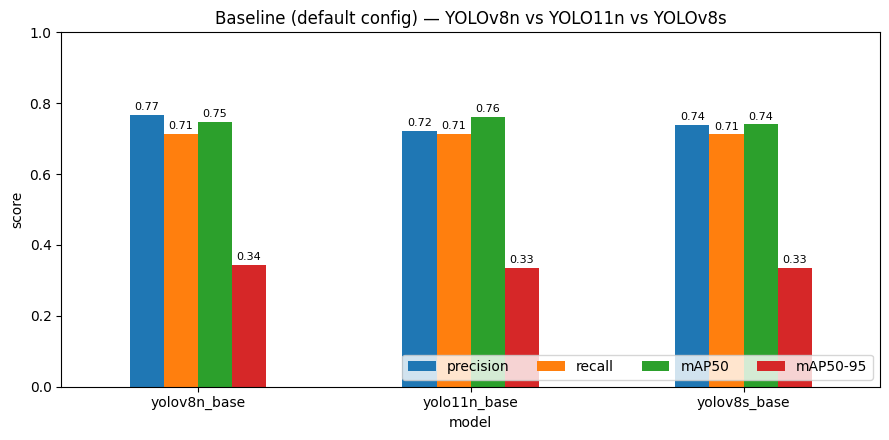

Best baseline by mAP@50-95: yolov8n_base
Observation template — comment on: n-vs-s accuracy gap, v8n-vs-11n at equal size, and whether Recall (small cigarettes) lags Precision.


In [19]:
# ── Baseline comparison plot ────────────────────────────────────────────────
metric_cols = ["precision", "recall", "mAP50", "mAP50-95"]
ax = baseline_df[metric_cols].plot(kind="bar", figsize=(9, 4.5), rot=0)
ax.set_title("Baseline (default config) — YOLOv8n vs YOLO11n vs YOLOv8s")
ax.set_ylabel("score"); ax.set_ylim(0, 1); ax.legend(loc="lower right", ncol=4)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout(); plt.show()

BEST_BASELINE = baseline_df["mAP50-95"].idxmax()
print(f"Best baseline by mAP@50-95: {BEST_BASELINE}")
print("Observation template — comment on: n-vs-s accuracy gap, v8n-vs-11n at equal size, "
      "and whether Recall (small cigarettes) lags Precision.")

## 7 · Hyperparameter tuning

**Model tuned.** We tune the strongest *accuracy‑per‑cost* candidate from §6 (defaults to the
best‑mAP baseline; override `TUNE_MODEL_TAG` to force e.g. `yolo11n` for the edge target).

**Search strategy.** A **guided manual search** over the highest‑leverage knobs, followed by an
optional **evolutionary search** (`model.tune()`, a genetic algorithm) to refine. Manual search
is used first because the space is small and each run is cheap on the candidate subset, which
keeps the study interpretable and reproducible.

**Hyper‑parameters explored &amp; rationale.**

| Hyper‑parameter | Values tried | Why it matters here |
|-----------------|--------------|---------------------|
| `lr0` (initial LR) | 0.01, 0.005, 0.001 | Dominant knob for fine‑tuning stability/convergence |
| `optimizer` | SGD, AdamW | AdamW often converges faster on small transfer sets |
| `cos_lr` | False, True | Cosine decay can improve late‑epoch mAP |
| `mosaic` / `close_mosaic` | 1.0, or off early | Train was **already augmented** in prep → too much in‑loop mosaic can hurt |
| `weight_decay` | 0.0005, 0.001 | Regularisation vs a modest‑sized set |

`imgsz` is **fixed at 640** (input contract) and is deliberately *not* searched.

We log every run's Precision/Recall/mAP, plot the sweep, and compare the **tuned** model against
its **baseline**.

In [30]:
# # ── Which model to tune + how long each trial runs ──────────────────────────
# TUNE_MODEL_TAG = BEST_BASELINE            # or set manually: "yolo11n" / "yolov8n" / "yolov8s"
# TUNE_WEIGHTS   = BASELINE_MODELS[TUNE_MODEL_TAG]
# EPOCHS_TUNE    = 20                       # shorter per-trial schedule
# PROJECT_TUNE   = "runs_m3/tuning"
# print("Tuning model:", TUNE_MODEL_TAG)

# # Guided manual grid — a small, high-leverage set of configurations (not a full cartesian blow-up)
# TRIALS = [
#     dict(name="t1_lr01_sgd",         lr0=0.01,  optimizer="SGD",   cos_lr=False, close_mosaic=10),
#     dict(name="t2_lr005_sgd_cos",    lr0=0.005, optimizer="SGD",   cos_lr=True,  close_mosaic=10),
#     dict(name="t3_lr001_adamw",      lr0=0.001, optimizer="AdamW", cos_lr=True,  close_mosaic=10),
#     dict(name="t4_lr005_adamw_wd",   lr0=0.005, optimizer="AdamW", cos_lr=True,  close_mosaic=10, weight_decay=0.001),
#     dict(name="t5_lr01_sgd_nomosaic",lr0=0.01,  optimizer="SGD",   cos_lr=True,  mosaic=0.0),
# ]

# tune_rows = []
# for cfg in TRIALS:
#     name = cfg.pop("name")
#     print(f"\n----- trial: {name} | {cfg} -----")
#     row, _ = train_eval(TUNE_WEIGHTS, name, SUBSET_YAML, EPOCHS_TUNE, PROJECT_TUNE, **cfg)
#     row["config"] = str(cfg)
#     tune_rows.append(row)

# tune_df = pd.DataFrame(tune_rows).set_index("model")
# print("\n================ TUNING TRIALS (candidate subset / val) ================")
# display(tune_df[["precision", "recall", "mAP50", "mAP50-95", "config"]].round(4))

In [31]:
# ── OPTIONAL: evolutionary (genetic) search via Ultralytics .tune() ──────────
# Uncomment to run. This mutates hyper-parameters over `iterations` generations and
# writes best_hyperparameters.yaml to the run dir. It is heavier — enable when you have time.
#
# YOLO(TUNE_WEIGHTS).tune(
#     data=str(SUBSET_YAML), imgsz=IMG_SIZE, epochs=EPOCHS_TUNE, iterations=20,
#     optimizer="AdamW", device=DEVICE, seed=SEED, plots=True, save=True, val=True,
#     project=PROJECT_TUNE, name="evolve",
# )
# print("Evolutionary search cell is optional — see comments above.")

In [32]:
# ── Tuning sweep plot + pick the winner ─────────────────────────────────────
# ax = tune_df[metric_cols].plot(kind="bar", figsize=(11, 4.5), rot=20)
# ax.set_title(f"Hyper-parameter sweep — {TUNE_MODEL_TAG}")
# ax.set_ylabel("score"); ax.set_ylim(0, 1); ax.legend(loc="lower right", ncol=4)
# plt.tight_layout(); plt.show()

# BEST_TRIAL = tune_df["mAP50-95"].idxmax()
# print(f"Best tuned config by mAP@50-95: {BEST_TRIAL}")
# print("Selected config:", tune_df.loc[BEST_TRIAL, "config"])

In [33]:
# ── Baseline vs Tuned — did tuning help? ────────────────────────────────────
# base_ref  = baseline_df.loc[TUNE_MODEL_TAG, metric_cols]
# tuned_ref = tune_df.loc[BEST_TRIAL, metric_cols]
# compare = pd.DataFrame({"baseline (default)": base_ref, "tuned (best)": tuned_ref})
# compare["Δ (abs)"]   = compare["tuned (best)"] - compare["baseline (default)"]
# compare["Δ (%)"]     = 100 * compare["Δ (abs)"] / compare["baseline (default)"].replace(0, np.nan)
# display(compare.round(4))

# ax = compare[["baseline (default)", "tuned (best)"]].plot(kind="bar", figsize=(9, 4.5), rot=0)
# ax.set_title(f"{TUNE_MODEL_TAG}: baseline vs tuned"); ax.set_ylim(0, 1); ax.set_ylabel("score")
# for c in ax.containers:
#     ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
# plt.tight_layout(); plt.show()
# print("Discuss: which metric improved most, and the accuracy/latency trade-off vs YOLOv8s.")

In [34]:
# ── (Optional) Training-curve comparison from results.csv ───────────────────
# Ultralytics writes a results.csv per run; overlay mAP50-95 curves for context.
# def load_curve(run_dir):
#     p = Path(run_dir) / "results.csv"
#     if not p.exists():
#         return None
#     d = pd.read_csv(p); d.columns = [c.strip() for c in d.columns]
#     col = next((c for c in d.columns if "mAP50-95" in c), None)
#     return d[["epoch", col]].rename(columns={col: "mAP50-95"}) if col else None

# plt.figure(figsize=(8, 4.5))
# for tag, r in baseline_df["run_dir"].items():
#     cur = load_curve(r)
#     if cur is not None:
#         plt.plot(cur["epoch"], cur["mAP50-95"], "--", label=f"{tag} (base)")
# best_dir = tune_df.loc[BEST_TRIAL, "run_dir"]
# cur = load_curve(best_dir)
# if cur is not None:
#     plt.plot(cur["epoch"], cur["mAP50-95"], lw=2.4, label=f"{BEST_TRIAL} (tuned)")
# plt.xlabel("epoch"); plt.ylabel("val mAP@50-95"); plt.title("Learning curves")
# plt.legend(); plt.tight_layout(); plt.show()

## 8 · End‑to‑end setup (input → predictions)

**1 · Input data flow.** Raw driver‑cabin frames → *(prep notebook)* clean, harmonised,
deduplicated, **real‑image‑balanced** YOLO dataset → this notebook loads it via `data.yaml`
→ **candidate subset** for experimentation. Every image enters the model letterboxed to
**640×640 RGB**, normalised to `[0,1]`.

**2 · Model architecture overview.** CSP backbone → PAN‑FPN neck (P3/P4/P5 multi‑scale fusion)
→ anchor‑free decoupled head predicting class logits + DFL box distributions for the 2 classes.
(Diagram in §9.)

**3 · Training pipeline.** COCO‑pretrained weights → head reset to `nc=2` → fine‑tune with
SGD/AdamW, warm‑up + (cosine) LR schedule, in‑loop augmentation (mosaic closed near the end),
loss = **box (CIoU) + classification (BCE) + DFL**.

**4 · Validation strategy.** Image‑grouped, class‑stratified `train/val/test` from prep (no
leakage). `val` fold drives model/HP selection; `test` fold is untouched until the final check
below.

**5 · Evaluation methodology.** Ultralytics `.val()` at IoU 0.50 and 0.50:0.95 → Precision,
Recall, mAP@50, mAP@50‑95, plus PR/confusion‑matrix plots.

**6 · Expected outputs.** Per detection: class ∈ {smoking, drinking}, box (x,y,w,h),
confidence — consumable by a downstream driver‑alert rule.

Below we lock in the winning config and run a **held‑out `test`** evaluation.

In [21]:
# # ── Final model on the candidate subset: train best config, evaluate on TEST ─
# best_cfg = eval(tune_df.loc[BEST_TRIAL, "config"])   # dict string -> dict
# print("Final config:", best_cfg)

# final_model = YOLO(TUNE_WEIGHTS)
# final_res = final_model.train(
#     data=str(SUBSET_YAML), imgsz=IMG_SIZE, epochs=EPOCHS_TUNE, batch=BATCH,
#     device=DEVICE, seed=SEED, project="runs_m3/final", name=f"{TUNE_MODEL_TAG}_final",
#     exist_ok=True, verbose=False, plots=True, **best_cfg,
# )

# # held-out TEST evaluation
# test_metrics = final_model.val(data=str(SUBSET_YAML), split="test", imgsz=IMG_SIZE,
#                                device=DEVICE, verbose=False)
# print("\n================ HELD-OUT TEST (candidate subset) ================")
# print(f"Precision : {test_metrics.box.mp:.4f}")
# print(f"Recall    : {test_metrics.box.mr:.4f}")
# print(f"mAP@50    : {test_metrics.box.map50:.4f}")
# print(f"mAP@50-95 : {test_metrics.box.map:.4f}")
# print("\nPer-class mAP@50-95:")
# for i, name in enumerate(CLASS_NAMES):
#     try:
#         print(f"  {name:9s}: {test_metrics.box.maps[i]:.4f}")
#     except Exception:
#         pass

In [26]:
# # ── Qualitative check: predictions on a few test images ─────────────────────
# test_imgs = sorted((SUBSET_DIR / "images" / "test").glob("*.*"))[:6]
# if test_imgs:
#     preds = final_model.predict(source=[str(p) for p in test_imgs], imgsz=IMG_SIZE,
#                                 conf=0.25, device=DEVICE, verbose=False)
#     n = len(preds); cols = 3; rows = (n + cols - 1) // cols
#     fig, axes = plt.subplots(rows, cols, figsize=(14, 4.6 * rows))
#     for ax, pr in zip(np.array(axes).ravel(), preds):
#         ax.imshow(pr.plot()[..., ::-1]); ax.axis("off")
#     for ax in np.array(axes).ravel()[n:]:
#         ax.axis("off")
#     plt.suptitle("Sample predictions (smoking / drinking)", y=1.0)
#     plt.tight_layout(); plt.show()
# else:
#     print("No test images found in the candidate subset.")


## 9 · Architecture visualization (pipeline + model)

Two views:
1. a labelled **end‑to‑end pipeline flowchart** (data → training → evaluation → outputs), and
2. the **layer‑level YOLO graph** printed by Ultralytics (`model.info()` / `model.model`).

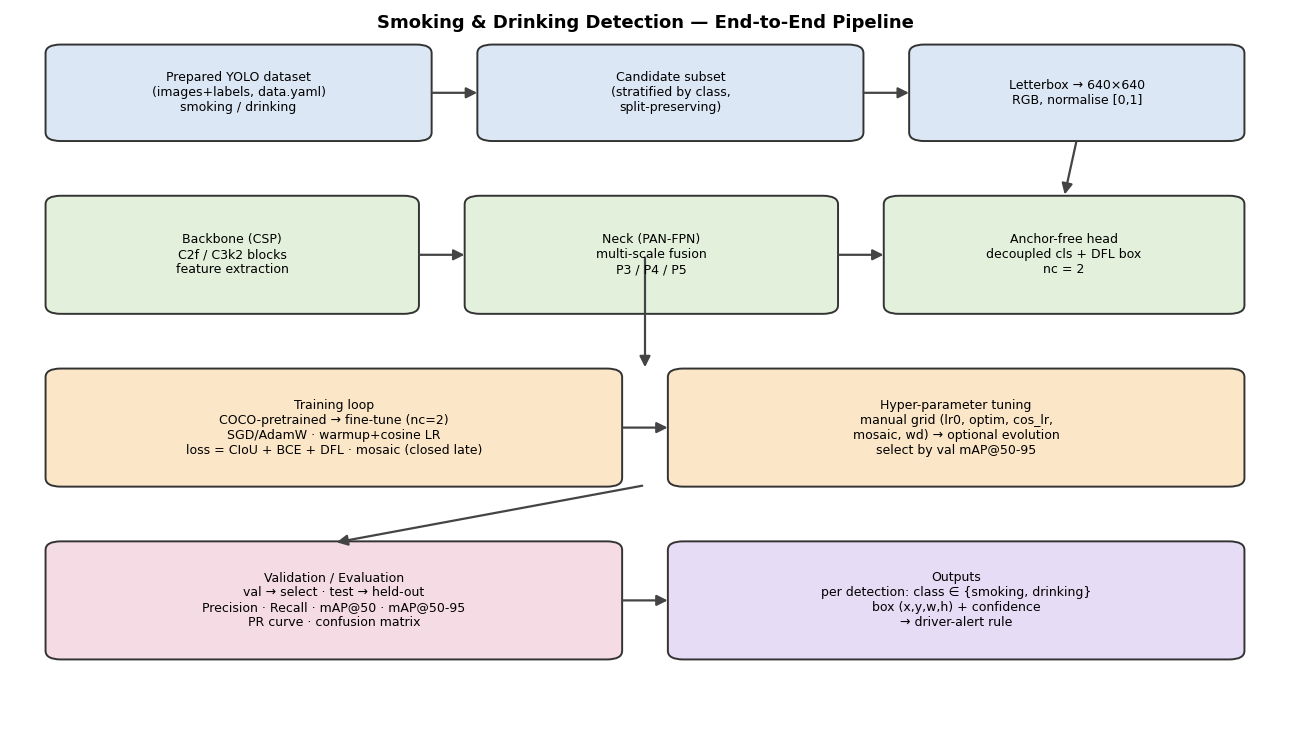

Saved: pipeline_diagram.png


In [27]:
# ── (a) End-to-end pipeline flowchart (self-contained, matplotlib) ──────────
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 7.5)); ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 10)

def box(x, y, w, h, text, fc):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.12",
                 linewidth=1.4, edgecolor="#333", facecolor=fc))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=9, wrap=True)

def arrow(p1, p2):
    ax.add_patch(FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=16,
                                 lw=1.6, color="#444"))

C1, C2, C3, C4, C5 = "#DCE7F5", "#E3F1DC", "#FBE6C8", "#F5DCE4", "#E7DCF5"
# Row 1 — data hand-off
box(0.3, 8.2, 3.0, 1.3, "Prepared YOLO dataset\n(images+labels, data.yaml)\nsmoking / drinking", C1)
box(3.7, 8.2, 3.0, 1.3, "Candidate subset\n(stratified by class,\nsplit-preserving)", C1)
box(7.1, 8.2, 2.6, 1.3, "Letterbox → 640×640\nRGB, normalise [0,1]", C1)
arrow((3.3, 8.85), (3.7, 8.85)); arrow((6.7, 8.85), (7.1, 8.85))
# Row 2 — model
box(0.3, 5.8, 2.9, 1.6, "Backbone (CSP)\nC2f / C3k2 blocks\nfeature extraction", C2)
box(3.6, 5.8, 2.9, 1.6, "Neck (PAN-FPN)\nmulti-scale fusion\nP3 / P4 / P5", C2)
box(6.9, 5.8, 2.8, 1.6, "Anchor-free head\ndecoupled cls + DFL box\nnc = 2", C2)
arrow((3.2, 6.6), (3.6, 6.6)); arrow((6.5, 6.6), (6.9, 6.6))
arrow((8.4, 8.2), (8.3, 7.4))  # input -> model
# Row 3 — training
box(0.3, 3.4, 4.5, 1.6, "Training loop\nCOCO-pretrained → fine-tune (nc=2)\nSGD/AdamW · warmup+cosine LR\nloss = CIoU + BCE + DFL · mosaic (closed late)", C3)
box(5.2, 3.4, 4.5, 1.6, "Hyper-parameter tuning\nmanual grid (lr0, optim, cos_lr,\nmosaic, wd) → optional evolution\nselect by val mAP@50-95", C3)
arrow((5.0, 6.6), (5.0, 5.0)); arrow((4.8, 4.2), (5.2, 4.2))
# Row 4 — eval + outputs
box(0.3, 1.0, 4.5, 1.6, "Validation / Evaluation\nval → select · test → held-out\nPrecision · Recall · mAP@50 · mAP@50-95\nPR curve · confusion matrix", C4)
box(5.2, 1.0, 4.5, 1.6, "Outputs\nper detection: class ∈ {smoking, drinking}\nbox (x,y,w,h) + confidence\n→ driver-alert rule", C5)
arrow((5.0, 3.4), (2.55, 2.6)); arrow((4.8, 1.8), (5.2, 1.8))

ax.text(5, 9.75, "Smoking & Drinking Detection — End-to-End Pipeline",
        ha="center", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("pipeline_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pipeline_diagram.png")

In [29]:
# # ── (b) Layer-level model architecture (Ultralytics) ────────────────────────
# arch_model = YOLO(BASELINE_MODELS[TUNE_MODEL_TAG])
# arch_model.info(detailed=False)          # params, GFLOPs, layer count
# # For the full layer graph, uncomment:
# # print(arch_model.model)
# #
# # Ultralytics also auto-saves a visual: after any training run, see
# #   <run_dir>/  ->  results.png, confusion_matrix.png, PR_curve.png, labels.jpg
# print("\nTip: training runs also save PR_curve.png, confusion_matrix.png, results.png in each run dir.")

## 10 · Report section (M3 write‑up)

> Fill the bracketed numbers from your run outputs before submitting.

**Problem.** Detect **smoking** and **drinking** actions from in‑cabin frames to flag unsafe
driver behaviour. Input **640×640 RGB**; outputs are class + box + confidence for two classes.

**Architectures selected.** YOLOv8n, YOLO11n, YOLOv8s — single‑stage, anchor‑free detectors
(CSP backbone · PAN‑FPN neck · decoupled DFL head). YOLOv8n is the reference; **YOLO11n** probes
the newer generation (C3k2 + C2PSA) at nano size; **YOLOv8s** probes added capacity.

**Justification (summary).** Chosen for real‑time in‑cabin latency, strong COCO transfer on a
moderate balanced dataset, and a favourable accuracy‑latency frontier vs two‑stage / DETR /
SSD alternatives. Head adapted to `nc=2`; `imgsz` fixed at 640; in‑loop augmentation kept light
because the train split was already augmented in prep.

**Candidate subset.** Built by **class‑stratified, split‑preserving** sampling
(train≈[30]%, val/test≈[60]%). Verified representative: class proportions and mean boxes/image
match the full set (see §5 table).

**Baseline (default config, candidate/val).**

| Model | Precision | Recall | mAP@50 | mAP@50‑95 |
|-------|-----------|--------|--------|-----------|
| YOLOv8n | [ ] | [ ] | [ ] | [ ] |
| YOLO11n | [ ] | [ ] | [ ] | [ ] |
| YOLOv8s | [ ] | [ ] | [ ] | [ ] |

Best baseline: **[model]** (mAP@50‑95 = [ ]).

**Hyper‑parameter tuning.** Guided manual grid over `lr0`, `optimizer`, `cos_lr`,
`mosaic/close_mosaic`, `weight_decay` (+ optional evolutionary search), selecting by val
mAP@50‑95. Best config: **[config]**. Tuning changed mAP@50‑95 by **[Δ]** vs baseline
(Precision [Δ], Recall [Δ]) — see §7 plots.

**Held‑out test (candidate).** Precision [ ] · Recall [ ] · mAP@50 [ ] · mAP@50‑95 [ ];
per‑class mAP: smoking [ ], drinking [ ].

**End‑to‑end &amp; visualization.** Full pipeline and labelled flowchart in §8–§9.

**Next (M4).** Retrain the winning architecture + config on the **full** dataset; consider the
YOLOv8s accuracy vs nano‑latency trade‑off for the deployment target.

### Appendix · Retrain the winner on the FULL dataset (M4 hook)
When ready, point `data=` at the **full** `data.yaml` and lengthen the schedule:

```python
YOLO(BASELINE_MODELS[TUNE_MODEL_TAG]).train(
    data=str(DATA_YAML), imgsz=640, epochs=100, batch=16,
    device=DEVICE, seed=SEED, project="runs_m4/full", name=f"{TUNE_MODEL_TAG}_full",
    **best_cfg,
)
```
